<a href="https://colab.research.google.com/github/AtikaDwiAr/Cookpad-Information-Retrieval/blob/main/Project_IR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Anggota Kelompok:
1. Atika Dwi Aryanti (23/511929/PA/21857)
2. Jocelin Marella Ramadhaniska (23/512463/PA/21882)
3. Iffa Hesti Adlik Putri (23/514098/PA/21977)
4. Meilany Dinda Talitha (23/517897/PA/22220)

# Preprocessing

### Install & Import Library

In [ ]:
!apt-get install openjdk-21-jdk -qq
!pip install pyserini
!pip install Sastrawi

import os, json, csv, string

Selecting previously unselected package fonts-dejavu-core.
(Reading database ... 126718 files and directories currently installed.)
Preparing to unpack .../00-fonts-dejavu-core_2.37-2build1_all.deb ...
Unpacking fonts-dejavu-core (2.37-2build1) ...
Selecting previously unselected package fonts-dejavu-extra.
Preparing to unpack .../01-fonts-dejavu-extra_2.37-2build1_all.deb ...
Unpacking fonts-dejavu-extra (2.37-2build1) ...
Selecting previously unselected package libxtst6:amd64.
Preparing to unpack .../02-libxtst6_2%3a1.2.3-1build4_amd64.deb ...
Unpacking libxtst6:amd64 (2:1.2.3-1build4) ...
Selecting previously unselected package libxxf86dga1:amd64.
Preparing to unpack .../03-libxxf86dga1_2%3a1.1.5-0ubuntu3_amd64.deb ...
Unpacking libxxf86dga1:amd64 (2:1.1.5-0ubuntu3) ...
Selecting previously unselected package x11-utils.
Preparing to unpack .../04-x11-utils_7.7+5build2_amd64.deb ...
Unpacking x11-utils (7.7+5build2) ...
Selecting previously unselected package libatk-wrapper-java.
Pre

In [ ]:
import gdown
import pandas as pd
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import nltk

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Download file dari google drive
file_id = "14Z7V8NTEpoqF7Uhk1jSPyEtHk3iotgLu"
url = f"https://drive.google.com/uc?id={file_id}"
input_csv = "resepbener.csv"
gdown.download(url, input_csv, quiet=False)

# Load csv
df = pd.read_csv(input_csv, sep=',', encoding='utf-8')

Downloading...
From: https://drive.google.com/uc?id=14Z7V8NTEpoqF7Uhk1jSPyEtHk3iotgLu
To: /content/resepbener.csv
100%|██████████| 580k/580k [00:00<00:00, 9.53MB/s]


In [ ]:
print(df.head())

  keyword                                    url  \
0    ayam  https://cookpad.com/id/resep/25017577   
1    ayam  https://cookpad.com/id/resep/25026783   
2    ayam  https://cookpad.com/id/resep/25026554   
3    ayam  https://cookpad.com/id/resep/25022283   
4    ayam  https://cookpad.com/id/resep/25027019   

                           judul  \
0        Ayam Suwir Sambal Matah   
1  36. Homemade Chicken Luncheon   
2             512. Luncheon Ayam   
3       Homemade Chicken Lucheon   
4               Chicken Luncheon   

                                               bahan  \
0  2 paha ayam,5 siung bawang putih, geprek,4 cm ...   
1  500 gr paha/ dada ayam fillet,60 gr putih telu...   
2  500 gr Paha Ayam Fillet,60 gr Putih Telur,50 g...   
3  500 gr paha ayam fillet,60 gr putih telur,50 g...   
4  500 gr paham ayam fillet,60 gr putih telur,50 ...   

                                             langkah  
0  Rebus ayam beserta semua bumbu rebusnya, masak...  
1  Siapkan bahan- bahan

### Preprocess

In [ ]:

# Persiapan preprocessing
factory = StemmerFactory()
stemmer = factory.create_stemmer()

stop_words = set(stopwords.words('indonesian'))

# Normalisasi domain resep
normalization_dict = {
    "gula pasir": "gula",
    "gula putih": "gula",
    "santan kelapa": "santan",
    "tepung terigu": "terigu",
    "coklat": "cokelat",
    "sup": "sop",
}

# Daftar satuan yang akan dihapus
satuan = [
    "gr", "kg", "ml", "l",    # berat / volume
    "sdt", "sdm",              # sendok teh / sendok makan
    "bh", "btg", "lbr", "cm", # buah, batang, lembar, cm
    "butir", "siung"
]

# Fungsi preprocessing
def preprocess_item(item):
    if pd.isnull(item):
        return ""
    # Lowercase
    item = item.lower()
    # Tokenisasi
    tokens = word_tokenize(item)
    # Hapus angka & simbol
    tokens = [re.sub(r'[^a-zA-Z]', '', t) for t in tokens]
    tokens = [t for t in tokens if t]  # buang token kosong
    # Stopword removal
    tokens = [t for t in tokens if t not in stop_words]
    # Stemming
    tokens = [stemmer.stem(t) for t in tokens]
    # Normalisasi domain
    tokens = [normalization_dict.get(t, t) for t in tokens]
    # Hapus satuan
    tokens = [t for t in tokens if t not in satuan]
    return " ".join(tokens)

def preprocess_bahan(text):
    if pd.isnull(text):
        return ""
    items = [i.strip() for i in text.split(',')]
    items = [preprocess_item(i) for i in items]
    return ", ".join(items)

def preprocess_langkah(text):
    if pd.isnull(text):
        return ""
    items = [i.strip() for i in text.split(',')]
    items = [preprocess_item(i) for i in items]
    return ". ".join(items)

# Menerapkan preprocessing
df_preprocessed = pd.DataFrame()
df_preprocessed['judul'] = df['judul'].apply(preprocess_item)
df_preprocessed['bahan'] = df['bahan'].apply(preprocess_bahan)
df_preprocessed['langkah'] = df['langkah'].apply(preprocess_langkah)

# Simpan hasil csv
df_preprocessed.to_csv("resep_preprocessed.csv", index=False, sep='\t', encoding='latin1') # Changed encoding to latin1

# Menampilkan 5 baris pertama
print(df_preprocessed.head())

                       judul  \
0    ayam suwir sambal matah   
1  homemade chicken luncheon   
2              luncheon ayam   
3   homemade chicken lucheon   
4           chicken luncheon   

                                               bahan  \
0  paha ayam, bawang putih, geprek, jahe, geprek,...   
1  paha dada ayam fillet, putih telur, bawang put...   
2  paha ayam fillet, putih telur, bawang putih ha...   
3  paha ayam fillet, putih telur, bawang putih, b...   
4  paham ayam fillet, putih telur, bawang putih, ...   

                                             langkah  
0  rebus ayam serta bumbu rebus. masak air susut ...  
1  siap bahan bahan halus bawang putih bawang bom...  
2  siap bahan. ayam segar wajib masuk freezer min...  
3  siap bahan fillet paha ayam segar masuk freeze...  
4  siap bahan. chopper bahan bentuk pasta kental ...  


# Indexing

### Pyserini

In [ ]:
def csv_to_jsonl(csv_path, json_path):
  with open(csv_path, mode="r", encoding="utf-8") as f_in, \
       open(json_path, mode="w", encoding="utf-8") as f_out:

       reader = csv.DictReader(f_in, delimiter="\t")
       for idx, row in enumerate(reader, start=1):
         # ambil tiap kolom
         judul = row.get("judul", "").strip()
         bahan = row.get("bahan", "").strip()
         langkah = row.get("langkah", "").strip()

         contents = f"Judul: {judul} | Bahan: {bahan} | Langkah: {langkah}"

         # tulis ke jsonl
         f_out.write(json.dumps({"id": "d"+str(idx), "contents": contents}) + "\n")

In [ ]:
os.makedirs("collections/resep_json", exist_ok=True)
csv_path = "resep_preprocessed.csv"
jsonl_path = "collections/resep_json/resep_corpus.jsonl"

csv_to_jsonl(csv_path, jsonl_path)

In [ ]:
!python -m pyserini.index.lucene \
  --collection JsonCollection \
  --input collections/resep_json \
  --index indexes/index_resep \
  --generator DefaultLuceneDocumentGenerator \
  --threads 1 \
  --language uspecified \
  --stemmer none \
  --storePositions --storeDocvectors --storeRaw --storeContents

2025-10-24 23:31:49,173 INFO  [main] index.AbstractIndexer (AbstractIndexer.java:205) - Setting log level to INFO
2025-10-24 23:31:49,178 INFO  [main] index.AbstractIndexer (AbstractIndexer.java:208) - ============ Loading Index Configuration ============
2025-10-24 23:31:49,179 INFO  [main] index.AbstractIndexer (AbstractIndexer.java:209) - AbstractIndexer settings:
2025-10-24 23:31:49,180 INFO  [main] index.AbstractIndexer (AbstractIndexer.java:210) -  + DocumentCollection path: collections/resep_json
2025-10-24 23:31:49,180 INFO  [main] index.AbstractIndexer (AbstractIndexer.java:211) -  + CollectionClass: JsonCollection
2025-10-24 23:31:49,180 INFO  [main] index.AbstractIndexer (AbstractIndexer.java:212) -  + Index path: indexes/index_resep
2025-10-24 23:31:49,182 INFO  [main] index.AbstractIndexer (AbstractIndexer.java:213) -  + Threads: 1
2025-10-24 23:31:49,182 INFO  [main] index.AbstractIndexer (AbstractIndexer.java:214) -  + Optimize (merge segments)? false
Oct 24, 2025 11:31:

# Query

### BM25 Baseline dengan Pyserini

In [ ]:
from pyserini.search.lucene import LuceneSearcher
import csv

searcher_resep = LuceneSearcher('indexes/index_resep')
searcher_resep.set_bm25(k1=0.9, b=0.4)

queries = {
    "ayam goreng": '"ayam goreng"',
    "nasi goreng": '"nasi goreng"',
    "bolu pisang": '"bolu pisang"',
    "sop buah naga": '"sop buah naga"',
    "cokelat kukus": '"cokelat kukus"'
}

print("BM25 Retrieval Results\n")

query_results = {}

for label, q in queries.items():
    hits_resep = searcher_resep.search(q, k=700)
    retrieved = [h.docid for h in hits_resep]
    query_results[label] = retrieved

    # tampilkan contoh 10 hasil teratas
    top10_results = hits_resep[:10]

    print(f"Query: {label}")
    for h in top10_results:
      print(f"  {h.docid}\t| score = {h.score:.4f}")
    print("-" * 50)

    print("Matched docs:")
    for h in top10_results:
        doc_resep = searcher_resep.doc(h.docid)

        resep_raw = doc_resep.contents() if doc_resep else ""

        print(f"ID: {h.docid}")
        print(f"{resep_raw}")
        print()
    print("=" * 60 + "\n")

BM25 Retrieval Results

Query: ayam goreng
  d22	| score = 1.8953
  d18	| score = 1.8412
  d71	| score = 1.8340
  d231	| score = 1.7772
  d91	| score = 1.7357
  d33	| score = 1.7336
  d79	| score = 1.7335
  d269	| score = 1.7129
  d52	| score = 1.7129
  d258	| score = 1.7107
--------------------------------------------------
Matched docs:
ID: d22
Judul: ayam goreng serundeng | Bahan: ekor ayam potong, buah jeruk nipis, kelapa parut, bungkus bumbu ayam ungkep yg halus, air, garam, sedap, buah bawang putih, iris tipis, gula aren, minyak goreng, daun jeruk, daun salam, daun pandan, batang serai, geprek | Langkah: cuci ayam bersih. jeruk nipis diam menit tumis bumbu ayam ungkep halus. tambah bumbu aromatik. tumis harum tambah potong ayam aduk bumbu campur. air ayam rendam tambah garam masak air susut tambah kelapa parut tambah sedap masak bumbu serap dalam kelapa parut. angkat ayam bumbu kelapa parut sisih masuk gula aren dalam bumbu kelapa parut. aduk angkat bumbu kelapa parut. peras air.

# Evaluasi

In [ ]:
# Download file dari google drive
file_id = "1LNAdpI_N-oURcMzHQo-OA4bi2dLvNp47"
url = f"https://drive.google.com/uc?id={file_id}"
input_csv = "ground_truth.csv"
gdown.download(url, input_csv, quiet=False)

# Load csv
df = pd.read_csv(input_csv, sep=',', encoding='utf-8')

Downloading...
From: https://drive.google.com/uc?id=1LNAdpI_N-oURcMzHQo-OA4bi2dLvNp47
To: /content/ground_truth.csv
100%|██████████| 797/797 [00:00<00:00, 2.63MB/s]


In [ ]:
ground_truth_loaded = {}
gt_df = pd.read_csv("ground_truth.csv")
for _, row in gt_df.iterrows():
    ground_truth_loaded[row["query"]] = row["relevant_docs"].split(";")

# contoh akses
print(ground_truth_loaded["ayam goreng"])


['d2', 'd6', 'd8', 'd20', 'd22', 'd33', 'd34', 'd35', 'd45', 'd68', 'd71', 'd72', 'd80', 'd82', 'd83', 'd84', 'd86', 'd91', 'd182', 'd205', 'd206', 'd207', 'd210', 'd231', 'd277', 'd282', 'd287', 'd297', 'd299', 'd503', 'd512']


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_results(results, ground_truth):
    eval_results = {}

    for q, retrieved in results.items():
        relevant = set(ground_truth.get(q, []))
        retrieved_set = set(retrieved)

        # universe dokumen untuk evaluasi
        all_docs = retrieved_set | relevant
        y_true = [1 if d in relevant else 0 for d in all_docs]
        y_pred = [1 if d in retrieved_set else 0 for d in all_docs]

        if not all_docs:  # kalau tidak ada dokumen
            continue

        # metrik
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        eval_results[q] = {
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "retrieved": len(retrieved_set),
            "relevant": len(relevant)
        }

    return eval_results

# --- Evaluasi Keseluruhan ---
def summarize_results(results):
    precisions = [res["precision"] for res in results.values()]
    recalls = [res["recall"] for res in results.values()]
    f1s = [res["f1"] for res in results.values()]

    summary = {
        "precision": sum(precisions) / len(precisions) if precisions else 0,
        "recall": sum(recalls) / len(recalls) if recalls else 0,
        "f1": sum(f1s) / len(f1s) if f1s else 0,
    }
    return summary


### Evaluasi BM25 Baseline

In [ ]:
# --- Jalankan Evaluasi Basic BM25 Query ---
baseline_eval = evaluate_results(query_results, ground_truth_loaded)

# --- Tampilkan per Query ---
print("\n=== Evaluasi BM25 ===")
for q, res in baseline_eval.items():
    print(f"Query: {q}")
    print(f"  Precision: {res['precision']:.4f}")
    print(f"  Recall   : {res['recall']:.4f}")
    print(f"  F1-score : {res['f1']:.4f}")
    print(f"  Retrieved: {res['retrieved']}, Relevant: {res['relevant']}")
    print("="*50)

# --- Tampilkan Keseluruhan ---
phrase_summary = summarize_results(baseline_eval)
print("\n=== Evaluasi Keseluruhan BM25 ===")
for metric, val in phrase_summary.items():
    print(f"{metric.capitalize()}: {val:.4f}")


=== Evaluasi BM25 ===
Query: ayam goreng
  Precision: 0.0807
  Recall   : 1.0000
  F1-score : 0.1494
  Retrieved: 384, Relevant: 31
Query: nasi goreng
  Precision: 0.1063
  Recall   : 1.0000
  F1-score : 0.1922
  Retrieved: 348, Relevant: 37
Query: bolu pisang
  Precision: 0.0943
  Recall   : 1.0000
  F1-score : 0.1724
  Retrieved: 159, Relevant: 15
Query: sop buah naga
  Precision: 0.1217
  Recall   : 1.0000
  F1-score : 0.2171
  Retrieved: 345, Relevant: 42
Query: cokelat kukus
  Precision: 0.1329
  Recall   : 1.0000
  F1-score : 0.2346
  Retrieved: 158, Relevant: 21

=== Evaluasi Keseluruhan BM25 ===
Precision: 0.1072
Recall: 1.0000
F1: 0.1931


### Tabel Evaluasi

In [ ]:
print("\n=== Evaluasi BM25 Per Query ===")
eval_df = pd.DataFrame.from_dict(baseline_eval, orient="index")
display(eval_df)

# Hasil keseluruhan
phrase_summary = summarize_results(baseline_eval)
summary_df = pd.DataFrame([phrase_summary])
print("\n=== Evaluasi Keseluruhan BM25 ===")
display(summary_df)



=== Evaluasi BM25 Per Query ===


,precision,recall,f1,retrieved,relevant
ayam goreng,0.080729,1.0,0.149398,384,31
nasi goreng,0.106322,1.0,0.192208,348,37
bolu pisang,0.094340,1.0,0.172414,159,15
sop buah naga,0.121739,1.0,0.217054,345,42
cokelat kukus,0.132911,1.0,0.234637,158,21



=== Evaluasi Keseluruhan BM25 ===


,precision,recall,f1
0,0.107208,1.0,0.193142


from matplotlib import pyplot as plt
_df_0['precision'].plot(kind='hist', bins=20, title='precision')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
_df_3['relevant'].plot(kind='hist', bins=20, title='relevant')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_4.groupby('index').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_5.plot(kind='scatter', x='precision', y='f1', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_6.plot(kind='scatter', x='f1', y='retrieved', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_7.plot(kind='scatter', x='retrieved', y='relevant', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

### Grafik Evaluasi

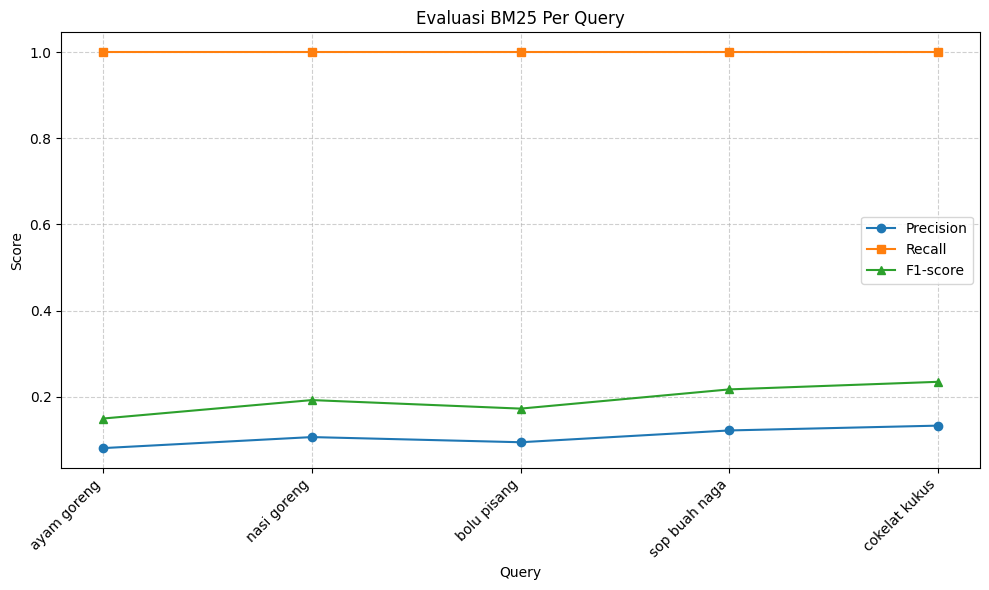

In [ ]:
import matplotlib.pyplot as plt

if not eval_df.empty:
    plt.figure(figsize=(10, 6))
    x = range(len(eval_df))
    plt.plot(x, eval_df["precision"], marker='o', label='Precision')
    plt.plot(x, eval_df["recall"], marker='s', label='Recall')
    plt.plot(x, eval_df["f1"], marker='^', label='F1-score')
    plt.xticks(x, eval_df.index, rotation=45, ha='right')
    plt.title("Evaluasi BM25 Per Query")
    plt.xlabel("Query")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Tidak ada hasil evaluasi yang dapat divisualisasikan.")

In [ ]:
!zip -r indexes.zip indexes

  adding: indexes/ (stored 0%)
  adding: indexes/index_resep/ (stored 0%)
  adding: indexes/index_resep/_0.nvm (deflated 26%)
  adding: indexes/index_resep/_0.nvd (deflated 25%)
  adding: indexes/index_resep/_0.fdt (deflated 20%)
  adding: indexes/index_resep/_0_Lucene99_0.doc (deflated 27%)
  adding: indexes/index_resep/_0_Lucene99_0.tim (deflated 35%)
  adding: indexes/index_resep/_0.tvm (deflated 28%)
  adding: indexes/index_resep/_0.tvx (deflated 2%)
  adding: indexes/index_resep/_0_Lucene99_0.tmd (deflated 22%)
  adding: indexes/index_resep/_0.fdx (deflated 3%)
  adding: indexes/index_resep/_0_Lucene90_0.dvd (deflated 50%)
  adding: indexes/index_resep/_0.fdm (deflated 28%)
  adding: indexes/index_resep/segments_1 (deflated 40%)
  adding: indexes/index_resep/_0.tvd (deflated 15%)
  adding: indexes/index_resep/_0_Lucene99_0.tip (deflated 24%)
  adding: indexes/index_resep/_0_Lucene90_0.dvm (deflated 36%)
  adding: indexes/index_resep/_0.fnm (deflated 52%)
  adding: indexes/index_re

In [ ]:
!zip -r collections.zip collections

  adding: collections/ (stored 0%)
  adding: collections/resep_json/ (stored 0%)
  adding: collections/resep_json/resep_corpus.jsonl (deflated 75%)
